In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import time
from numba import jit
from matplotlib.colors import LogNorm

Define the Grains:

Read in the grain information from the csv file of the form: (x position, y position, feature ID).
Crop the area.

In [3]:
# Read in the grain information from the file

raw_grain = np.genfromtxt('NodeType3.csv', delimiter=';', skip_header=True)

# Define the ranges and steps
x_start, x_end, x_step = np.min(raw_grain[:, 0]), np.max(raw_grain[:, 0]), 0.25
y_start, y_end, y_step = np.min(raw_grain[:, 1]), np.max(raw_grain[:, 1]), 0.25

# Create arrays for the x and y indices based on the start, end, and step
x_indices = np.arange(x_start, x_end + x_step, x_step)
y_indices = np.arange(y_start, y_end + y_step, y_step)

# Create an empty array with the desired shape
grain_orientation = np.full((len(x_indices), len(y_indices)), -1)  # Assuming -1 for unfilled values

# Iterate over the raw_grain to populate the new array
for entry in raw_grain:
    x_pos, y_pos, feature_id = entry
    # Find the corresponding x and y index
    x_idx = np.where(x_indices == x_pos)[0][0]  # Find index in x_indices
    y_idx = np.where(y_indices == y_pos)[0][0]  # Find index in y_indices
    
    # Assign the FeatureId to the grain_orientation at the correct position
    grain_orientation[x_idx, y_idx] = feature_id

# Now grain_orientation isttopulated with the FeatureIds at the correct (x, y) positions.

# Crop the image
from_x = 15
to_x = 170
from_y = 11
to_y = 170

grain_orientation = grain_orientation[from_x:to_x, from_y:to_y]
x_indices = x_indices[from_x:to_x]
y_indices = y_indices[from_y:to_y]

In [10]:
np.max(grain_orientation)

np.int64(192)

Plot the grains

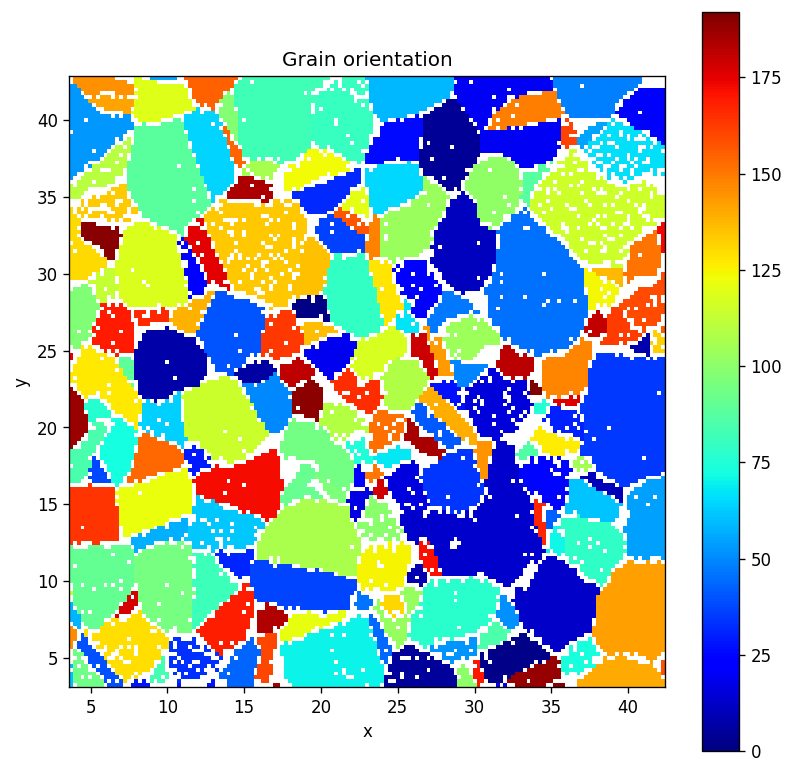

In [27]:
masked_orientation = np.ma.masked_where(grain_orientation == -1, grain_orientation) # remove the points that have been assigned -1 where no orientation was found

plt.figure(figsize=(8, 8), dpi=120)
plt.title("Grain orientation")
plt.xlabel("x")
plt.ylabel("y")

# Plot the masked data
plt.imshow(
    masked_orientation.T, 
    cmap=plt.cm.jet, 
    vmin=0, 
    # vmax=np.max(masked_orientation), 
    origin='lower',
    extent=[x_indices[0] - 0.125, x_indices[-1] + 0.125, 
            y_indices[0] - 0.125, y_indices[-1] + 0.125]
)

plt.colorbar()
plt.show()

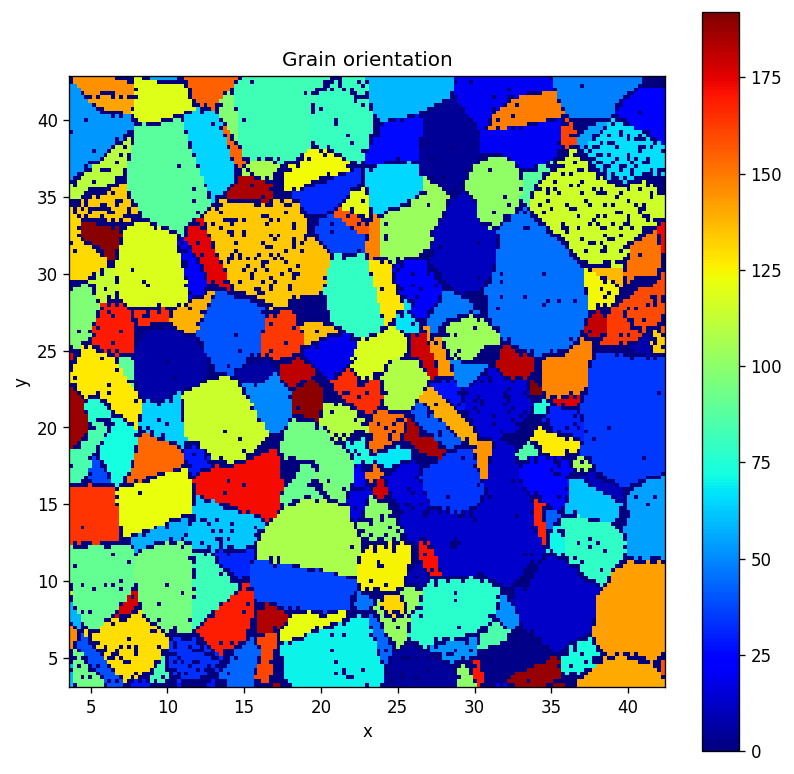

<Figure size 640x480 with 0 Axes>

In [18]:
# Plot the grains

plt.figure(figsize=(8, 8), dpi=120)
plt.title(f"Grain orientation")
plt.xlabel("x")
plt.ylabel("y")
plt.imshow(grain_orientation.T, cmap=plt.cm.jet, vmin=0, vmax=192, origin='lower', 
           extent=[x_indices[0] - 0.125, x_indices[-1] + 0.125, y_indices[0] - 0.125, y_indices[-1] + 0.125])
plt.colorbar()
plt.show()
plt.savefig('Grain_orientation.png')

Define the diffusion solver and plotting methods

In [5]:
max_iter_time = 200
alpha = 1
delta_t = (x_step ** 2)/(4 * alpha)
gamma = (alpha * delta_t) / (x_step ** 2)

# Initialize solution: the grid of H(t, i, j)
H = np.empty((max_iter_time, grain_orientation.shape[0], grain_orientation.shape[1]))

# Initial condition everywhere inside the grid
H_initial = 0

# Boundary conditions
H_bottom = 1e15
# H_top = 0.0
# H_left = 0.0
# H_right = 0.0

# Set the initial condition
H.fill(H_initial)

# Set the boundary conditions
H[:, :, 0] = H_bottom   # y=0
# H[:, 0, :] = H_left  # x=0
# H[:, -1, :] = H_right  # x=max
# H[:, :, -1] = H_top  # y=max

@jit(nopython=True)
def calculate(H):

    neighbors_offset = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]])
    for t in range(0, max_iter_time-1, 1):

        H_t = H[t]
        H_t_next = H[t + 1]

        for i in range(0, len(H[0, :, 0])):
            for j in range(1, len(H[0, 0, :]) - 1):
                current_orientation = grain_orientation[i, j]

                # Check if the current point is on a grain boundary
                on_boundary = False
                if current_orientation == -1:
                    on_boundary = True

                else:
                    # Check neighbors manually
                    for di, dj in neighbors_offset:
                        ni, nj = i + di, j + dj
                        if 0 <= ni < grain_orientation.shape[0] and 0 <= nj < grain_orientation.shape[1]: 
                            if grain_orientation[ni, nj] != current_orientation:
                                on_boundary = True
                                break  # Exit the loop as we found a boundary

                if on_boundary:
                    # Perform the diffusion calculation if on boundary
                    H_t_next[i, j] = gamma * ( H_t[i+1][j] +  H_t[i-1][j] +  H_t[i][j+1] +  H_t[i][j-1] - 4* H_t[i][j]) +  H_t[i][j]

                # else:
                #     H_t_next[i, j] = 0.01 * gamma * ( H_t[i+1][j] +  H_t[i-1][j] +  H_t[i][j+1] +  H_t[i][j-1] - 4* H_t[i][j]) +  H_t[i][j]

    return H

def plotheatmap(H_t, t):

    # Clear the current plot figure
    plt.clf()

    plt.title(f"Concentration at t = {t*delta_t:.3f} unit time")
    plt.xlabel("x")
    plt.ylabel("y")

    # This is to plot H_t (H at time-step t)
    
    logH = H_t.T + 1 #Adds a small constant so that we avoid taking the log of 0, transposed so that x and y axes are plotted correctly
    plt.imshow(logH, cmap=plt.cm.jet, norm=LogNorm(vmin=1, vmax=H_bottom), origin='lower', 
           extent=[x_indices[0] - 0.125, x_indices[-1] + 0.125, y_indices[11] - 0.125, y_indices[-1] + 0.125])
    plt.colorbar()

    return plt

def animate(t):
    plotheatmap(H[t], t)

Do the calculation

In [6]:
# Do the calculation here
H = calculate(H)

Show the heat map at the last time step

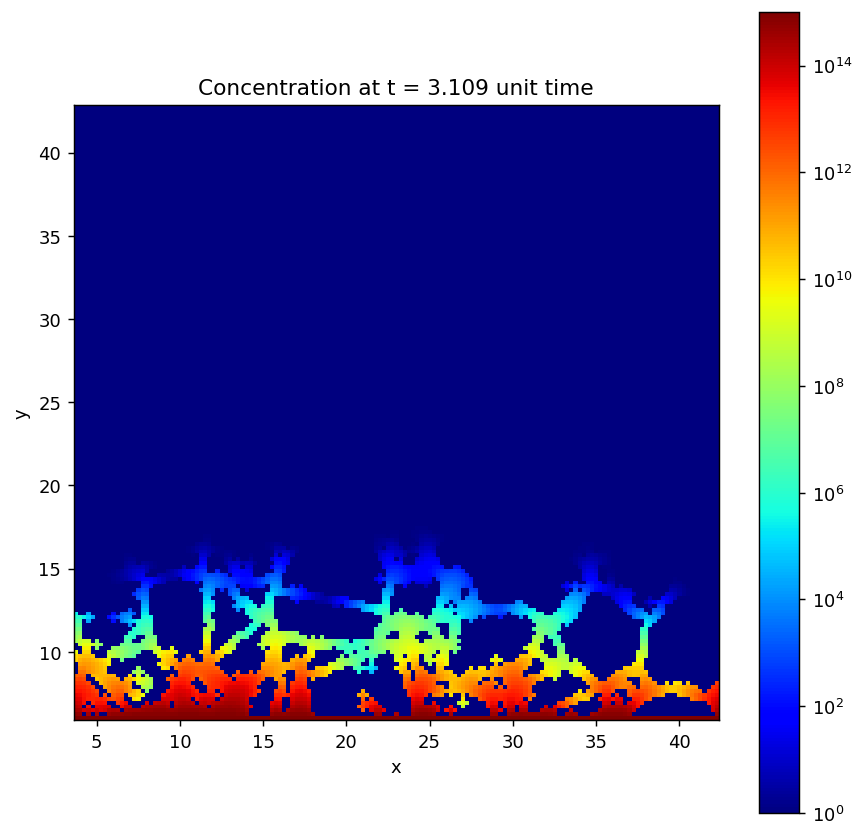

In [28]:
fig = plt.figure(figsize=(8, 8), dpi=130)
animate(max_iter_time - 1)

Create the animation

MovieWriter ffmpeg unavailable; using Pillow instead.


<Figure size 1000x1000 with 0 Axes>

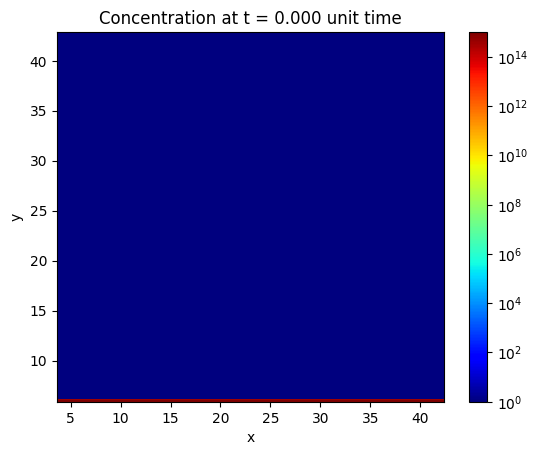

In [8]:
fig = plt.figure(figsize=(10, 10))
anim = FuncAnimation(plt.figure(), animate, interval=1, frames=max_iter_time, repeat=False)
anim.save("H_diffusion_jit.gif", dpi=200)